1000 Datapoints in dataset

900 Yes and 100 No

- 900 : 100 -> 9 : 1 [Imbalanced Dataset]
- 500 : 500 -> 1 : 1 [Balanced Dataset]
- 600 : 400 -> 6 : 4 [Balanced Dataset]
- 700 : 300 -> 7 : 3 [Can be imbalanced or balanced according to the condition]

Techniques to handle imbalanced dataset
- Upsampling

Idea:
Duplicate or synthetically generate more samples for the minority class to balance the dataset.

- Downsampling

Idea:
Reduce the number of samples from the majority class so both classes have similar counts.

In [1]:
import pandas as pd
import numpy as np

In [2]:
n_class_0 = 900
n_class_1 = 100

In [3]:
# Creating a dataset for class 0 (majority class)
class_0 = pd.DataFrame({
    # Generate 900 random values for 'feature_1'
    # following a normal distribution with mean = 0 and standard deviation = 1
    'feature_1': np.random.normal(0, 1, 900),

    # Generate 900 random values for 'feature_2'
    # also from the same normal distribution (mean = 0, std = 1)
    'feature_2': np.random.normal(0, 1, 900),

    # Create a 'target' column filled with 0s (representing class 0)
    'target': [0] * 900
})


In [4]:
[0]*5

[0, 0, 0, 0, 0]

In [5]:
class_0.head()

,feature_1,feature_2,target
0,0.769826,0.862180,0
1,-0.920655,0.251004,0
2,0.519254,1.121095,0
3,-0.462658,-1.596782,0
4,0.899630,-0.028483,0


In [6]:
class_0['target'].value_counts()

target
0    900
Name: count, dtype: int64

In [7]:
# Creating a dataset for class 1 (minority class)
class_1 = pd.DataFrame({
    # Generate 100 random values for 'feature_1'
    # following a normal distribution with mean = 2 and standard deviation = 1
    # (shifted to the right compared to class_0 which had mean = 0)
    'feature_1': np.random.normal(2, 1, 100),

    # Generate 100 random values for 'feature_2'
    # also from the same normal distribution (mean = 2, std = 1)
    'feature_2': np.random.normal(2, 1, 100),

    # Create a 'target' column filled with 1s (representing class 1)
    'target': [1] * 100
})


In [8]:
class_1

,feature_1,feature_2,target
0,2.720060,2.583545,1
1,2.364436,1.813228,1
2,2.318009,0.993066,1
3,1.380260,1.149954,1
4,3.128179,2.722060,1
...,...,...,...
95,-0.203401,0.075655,1
96,2.723311,1.813220,1
97,2.106567,2.153578,1
98,2.030155,2.110087,1


In [33]:
class_1['target'].value_counts()

target
1    100
Name: count, dtype: int64

In [9]:
class_0.shape, class_1.shape

((900, 3), (100, 3))

In [34]:
df = pd.concat([class_0, class_1],axis=0).reset_index(drop = True)

In [35]:
df.shape

(1000, 3)

In [37]:
df.sample(20)

,feature_1,feature_2,target
980,-0.042270,1.216224,1
845,-1.204767,-0.772174,0
951,1.376087,1.202733,1
677,0.169110,0.382834,0
24,0.216757,1.208313,0
460,-0.562744,0.032106,0
50,0.614599,0.688758,0
403,0.873089,-0.561521,0
290,0.455672,-0.994989,0
994,1.419577,2.866432,1


In [13]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [14]:
df.tail()

,feature_1,feature_2,target
995,-0.203401,0.075655,1
996,2.723311,1.813220,1
997,2.106567,2.153578,1
998,2.030155,2.110087,1
999,3.164130,4.191720,1


In [15]:
df.shape

(1000, 3)

In [16]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

<Axes: xlabel='feature_1', ylabel='feature_2'>

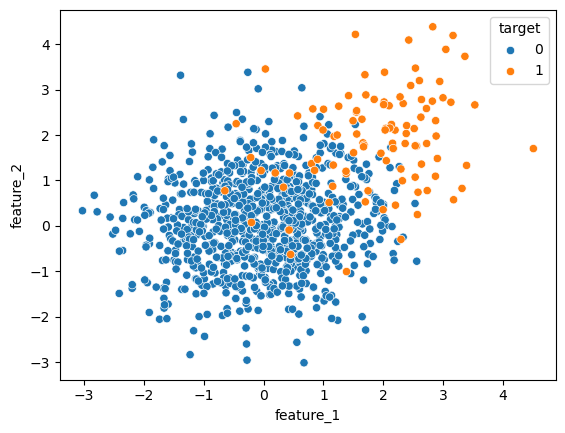

In [17]:
import seaborn as sns
sns.scatterplot(data=df, x='feature_1', y='feature_2', hue='target')

Upsampling

In [18]:
df_minority = df[df['target'] == 1]
df_majority = df[df['target'] == 0]

In [19]:
df_majority.shape, df_minority.shape

((900, 3), (100, 3))

In [20]:
len(df_majority), len(df_minority)

(900, 100)

In [21]:
from sklearn.utils import resample

df_minority_upsampled = resample(df_minority, replace = True, n_samples = len(df_majority))

In [38]:
df_minority.shape,df_minority_upsampled.shape

((100, 3), (900, 3))

In [43]:
df_majority_downsampled = resample(df_majority, replace = False, n_samples = len(df_minority))

In [41]:
df_majority.shape,df_majority_downsampled.shape

((900, 3), (100, 3))

In [44]:
df_upsampled = pd.concat([df_majority, df_minority_upsampled]).reset_index(drop = True)
df_upsampled.head()

,feature_1,feature_2,target
0,0.769826,0.862180,0
1,-0.920655,0.251004,0
2,0.519254,1.121095,0
3,-0.462658,-1.596782,0
4,0.899630,-0.028483,0


In [45]:
df_upsampled['target'].value_counts()

target
0    900
1    900
Name: count, dtype: int64

<Axes: xlabel='feature_1', ylabel='feature_2'>

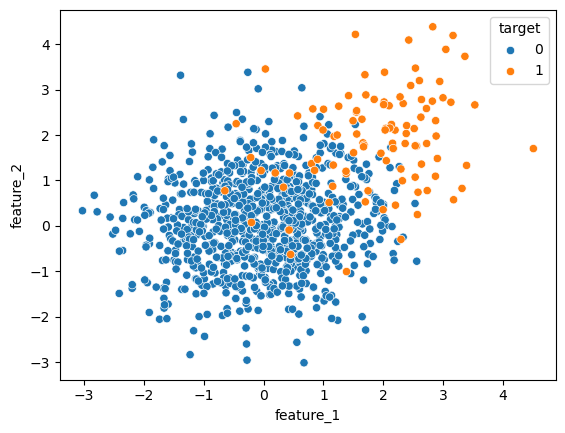

In [46]:
sns.scatterplot(data=df, x='feature_1', y='feature_2', hue='target')

<Axes: xlabel='feature_1', ylabel='feature_2'>

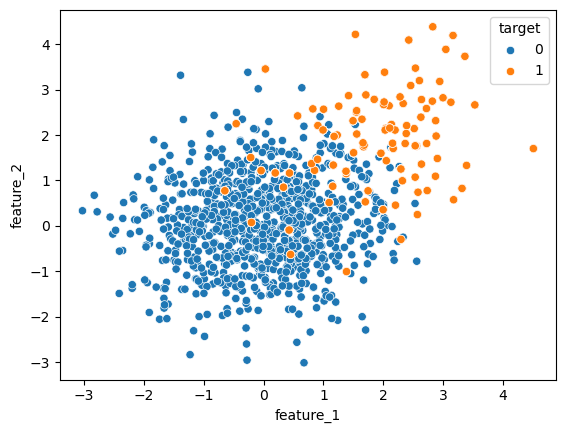

In [47]:
sns.scatterplot(data=df_upsampled, x='feature_1', y='feature_2', hue='target')


In [28]:
df.shape

(1800, 3)

In [ ]:
df = pd.concat([df_minority, df_majority_downsampled]).reset_index(drop=True)
df.shape

(200, 3)

In [30]:
df['target'].value_counts()

target
1    100
0    100
Name: count, dtype: int64

<Axes: xlabel='feature_1', ylabel='feature_2'>

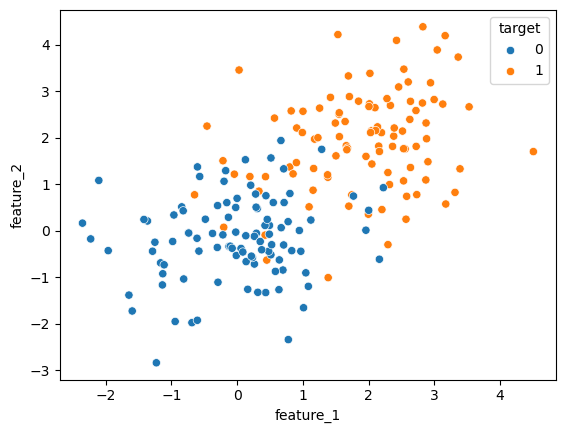

In [31]:
sns.scatterplot(data=df, x='feature_1', y='feature_2', hue='target')